In [1]:
# ================================
# Cell 1: Imports
# ================================

import os,random,time,copy,json,warnings
from pathlib import Path
from scipy import ndimage as ndi
import matplotlib.pyplot as plt

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torch.cuda.amp import autocast,GradScaler

import torchvision
import torchvision.transforms.functional as TF

from sklearn.metrics import confusion_matrix

In [2]:
# ================================
# Cell 2: Data loading and federated client split
# C2, C4, C6 = 1 training image each
# ================================
DATA_ROOT=Path("path/to/axon_dataset")
HEALTHY_ROOT=DATA_ROOT/"healthy axons"
DAMAGED_ROOT=DATA_ROOT/"damaged axons"
AXONDEEP_ROOT=DATA_ROOT/"axondeep"
MONTAGE_ROOT=DATA_ROOT/"new montage"

IMG_EXTS={".png",".jpg",".jpeg",".tif",".tiff",".bmp"}
NUM_CLASSES=3
CLASS_NAMES=["background","healthy","damaged"]
PATCH_SIZE=512
PATCH_OVERLAP=96
PATCH_STRIDE=PATCH_SIZE-PATCH_OVERLAP
BASE_SCALE=2.0
BASE_GAP=7
MONTAGE_TRAIN_CFG=[(2.0,5),(3.125,7)]
TEST_CFG={"original":(BASE_SCALE,BASE_GAP),"axondeep":(BASE_SCALE,BASE_GAP),
          "new_montage":(BASE_SCALE,BASE_GAP)}
SPLIT_SEED=42

def list_images(folder):
    return sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)

def find_mask(img_path,label_dir):
    s=img_path.stem
    names=[f"{s}_mask{img_path.suffix}",f"{s}.mask{img_path.suffix}",f"{s}_mask.png",
           f"{s}.mask.png",f"{s}_mask.tif",f"{s}.mask.tif",f"{s}.png",f"{s}.tif",f"{s}.tiff"]
    return next((label_dir/n for n in names if (label_dir/n).exists()),None)

def read_image(path,scale):
    with Image.open(path) as im:
        im=im.convert("RGB");w0,h0=im.size
        w,h=round(w0*scale),round(h0*scale)
        x=np.asarray(im.resize((w,h),Image.BILINEAR),np.float32)/255.
    return x.transpose(2,0,1),(h0,w0)

def read_mask(path,orig_hw,scale):
    h0,w0=orig_hw;h,w=round(h0*scale),round(w0*scale)
    if path is None:return np.zeros((h,w),bool)
    with Image.open(path) as m:
        return np.asarray(m.convert("L").resize((w,h),Image.NEAREST),np.uint8)>0

def make_label(h,d):
    y=np.zeros(h.shape,np.int64);y[h]=1;y[d]=2
    return y

def contact_map(label,gap=7):
    fg=label>0;n,cc=cv2.connectedComponents(fg.astype(np.uint8),8)
    if n<=2:return np.zeros((1,*label.shape),np.float32)
    dist,ind=ndi.distance_transform_edt(~fg,return_indices=True)
    nearest=cc[ind[0],ind[1]];k=np.ones((3,3),np.uint8)
    c=(nearest>0)&(cv2.dilate(nearest.astype(np.float32),k)!=cv2.erode(nearest.astype(np.float32),k))&(dist>0)&(dist<=gap)
    return cv2.dilate(c.astype(np.uint8),k,iterations=1)[None].astype(np.float32)

def patchify(x,y,c):
    _,h,w=x.shape
    if h<PATCH_SIZE or w<PATCH_SIZE:return [],[],[]
    ys=list(range(0,h-PATCH_SIZE+1,PATCH_STRIDE));xs=list(range(0,w-PATCH_SIZE+1,PATCH_STRIDE))
    if ys[-1]!=h-PATCH_SIZE:ys.append(h-PATCH_SIZE)
    if xs[-1]!=w-PATCH_SIZE:xs.append(w-PATCH_SIZE)
    X,Y,C=[],[],[]
    for yy in ys:
        for xx in xs:
            X.append(x[:,yy:yy+PATCH_SIZE,xx:xx+PATCH_SIZE])
            Y.append(y[yy:yy+PATCH_SIZE,xx:xx+PATCH_SIZE])
            C.append(c[:,yy:yy+PATCH_SIZE,xx:xx+PATCH_SIZE])
    return X,Y,C

def get_dirs(source,split):
    if source=="original":
        return HEALTHY_ROOT/split/"images",HEALTHY_ROOT/split/"labels",DAMAGED_ROOT/split/"labels"
    root=AXONDEEP_ROOT if source=="axondeep" else MONTAGE_ROOT
    return root/split/"images",root/split/"labels"/"healthy",root/split/"labels"/"damaged"

def split_extreme(source,split,seed):
    img_dir,_,_=get_dirs(source,split)
    names=np.array([p.name for p in list_images(img_dir)])
    rng=np.random.default_rng(seed);rng.shuffle(names)
    small=names[:1].tolist()
    large=names[1:].tolist()
    return large,small

def load_source(source,split,names,scale=2.,gap=7,patches=True,require_both=False):
    img_dir,h_dir,d_dir=get_dirs(source,split)
    X,Y,C,out_names,shapes,missing=[],[],[],[],[],[]
    for name in tqdm(names,desc=f"{source} {split} {scale:g}x",leave=False):
        ip=img_dir/name;hp,dp=find_mask(ip,h_dir),find_mask(ip,d_dir)
        if (require_both and (hp is None or dp is None)) or (hp is None and dp is None):
            missing.append(name);continue
        x,hw=read_image(ip,scale)
        y=make_label(read_mask(hp,hw,scale),read_mask(dp,hw,scale))
        c=contact_map(y,gap)
        if patches:
            xx,yy,cc=patchify(x,y,c);X+=xx;Y+=yy;C+=cc
        else:
            X.append(x);Y.append(y);C.append(c);out_names.append(ip.stem);shapes.append(hw)
    return X,Y,C,out_names,shapes,missing

def pack(X,Y,C):
    return {"X":np.stack(X).astype(np.float32),
            "Y":np.stack(Y).astype(np.int64),
            "C":np.stack(C).astype(np.float32)}

# ---------- deterministic extreme image-level splits ----------
# Large client gets N-1 images; small client gets exactly 1 image
o_tr1,o_tr2=split_extreme("original","train",42)
o_va1,o_va2=split_extreme("original","val",142)

a_tr1,a_tr2=split_extreme("axondeep","train",242)
a_va1,a_va2=split_extreme("axondeep","val",342)

m_tr1,m_tr2=split_extreme("new_montage","train",442)

# New montage: both C5/C6 use same test image as validation
montage_test_names=[p.name for p in list_images(MONTAGE_ROOT/"test"/"images")]
m_va1=montage_test_names
m_va2=montage_test_names

CLIENT_NAMES={
    "C1":{"source":"original","train":o_tr1,"val":o_va1},
    "C2":{"source":"original","train":o_tr2,"val":o_va2},
    "C3":{"source":"axondeep","train":a_tr1,"val":a_va1},
    "C4":{"source":"axondeep","train":a_tr2,"val":a_va2},
    "C5":{"source":"new_montage","train":m_tr1,"val":m_va1},
    "C6":{"source":"new_montage","train":m_tr2,"val":m_va2}}

CLIENT_DATA={}

for cid,d in CLIENT_NAMES.items():
    src=d["source"];Xtr,Ytr,Ctr,Xv,Yv,Cv=[],[],[],[],[],[]

    if src=="new_montage":
        for scale,gap in MONTAGE_TRAIN_CFG:
            a,b,c,_,_,_=load_source(src,"train",d["train"],scale,gap,True)
            Xtr+=a;Ytr+=b;Ctr+=c
        a,b,c,_,_,_=load_source(src,"test",d["val"],BASE_SCALE,BASE_GAP,True)
        Xv+=a;Yv+=b;Cv+=c
    else:
        Xtr,Ytr,Ctr,_,_,_=load_source(src,"train",d["train"],BASE_SCALE,BASE_GAP,True,src=="original")
        Xv,Yv,Cv,_,_,_=load_source(src,"val",d["val"],BASE_SCALE,BASE_GAP,True,src=="original")

    CLIENT_DATA[cid]={"train":pack(Xtr,Ytr,Ctr),"val":pack(Xv,Yv,Cv),"source":src,
                      "train_images":d["train"],"val_images":d["val"]}

    print(f"{cid} {src:11s} | train images={len(d['train']):2d}, patches={len(Xtr):4d} | "
          f"val images={len(d['val']):2d}, patches={len(Xv):4d}")

# ---------- global test sets unchanged ----------
def load_test(source):
    scale,gap=TEST_CFG[source]
    names=[p.name for p in list_images(get_dirs(source,"test")[0])]
    X,Y,_,nm,shapes,miss=load_source(source,"test",names,scale,gap,False,source=="original")
    print(f"{source} test: {len(X)} images | missing={len(miss)}")
    return {"images":X,"labels":Y,"names":nm,"shapes":shapes,
            "scale":scale,"missing":miss}

TEST_SETS={name:load_test(name) for name in TEST_CFG}

# Same global normalization using training data from all six clients
all_X=np.concatenate([CLIENT_DATA[c]["train"]["X"] for c in CLIENT_DATA])
n=all_X.shape[0]*all_X.shape[2]*all_X.shape[3]
MEAN=(all_X.sum((0,2,3),dtype=np.float64)/n).astype(np.float32)
VAR=np.square(all_X,dtype=np.float64).sum((0,2,3))/n-MEAN.astype(np.float64)**2
STD=np.sqrt(np.maximum(VAR,1e-12)).astype(np.float32)
del all_X

print("\nTrain mean:",MEAN.tolist())
print("Train std: ",STD.tolist())

original train 2x:   0%|          | 0/61 [00:00<?, ?it/s]

original val 2x:   0%|          | 0/8 [00:00<?, ?it/s]

C1 original    | train images=61, patches=1503 | val images= 8, patches= 200


original train 2x:   0%|          | 0/1 [00:00<?, ?it/s]

original val 2x:   0%|          | 0/1 [00:00<?, ?it/s]

...

original test: 18 images | missing=0


axondeep test 2x:   0%|          | 0/18 [00:00<?, ?it/s]

axondeep test: 18 images | missing=0


new_montage test 2x:   0%|          | 0/1 [00:00<?, ?it/s]

new_montage test: 1 images | missing=0

Train mean: [0.757270097732544, 0.757270097732544, 0.757270097732544]
Train std:  [0.09223967790603638, 0.09223972260951996, 0.09223981201648712]


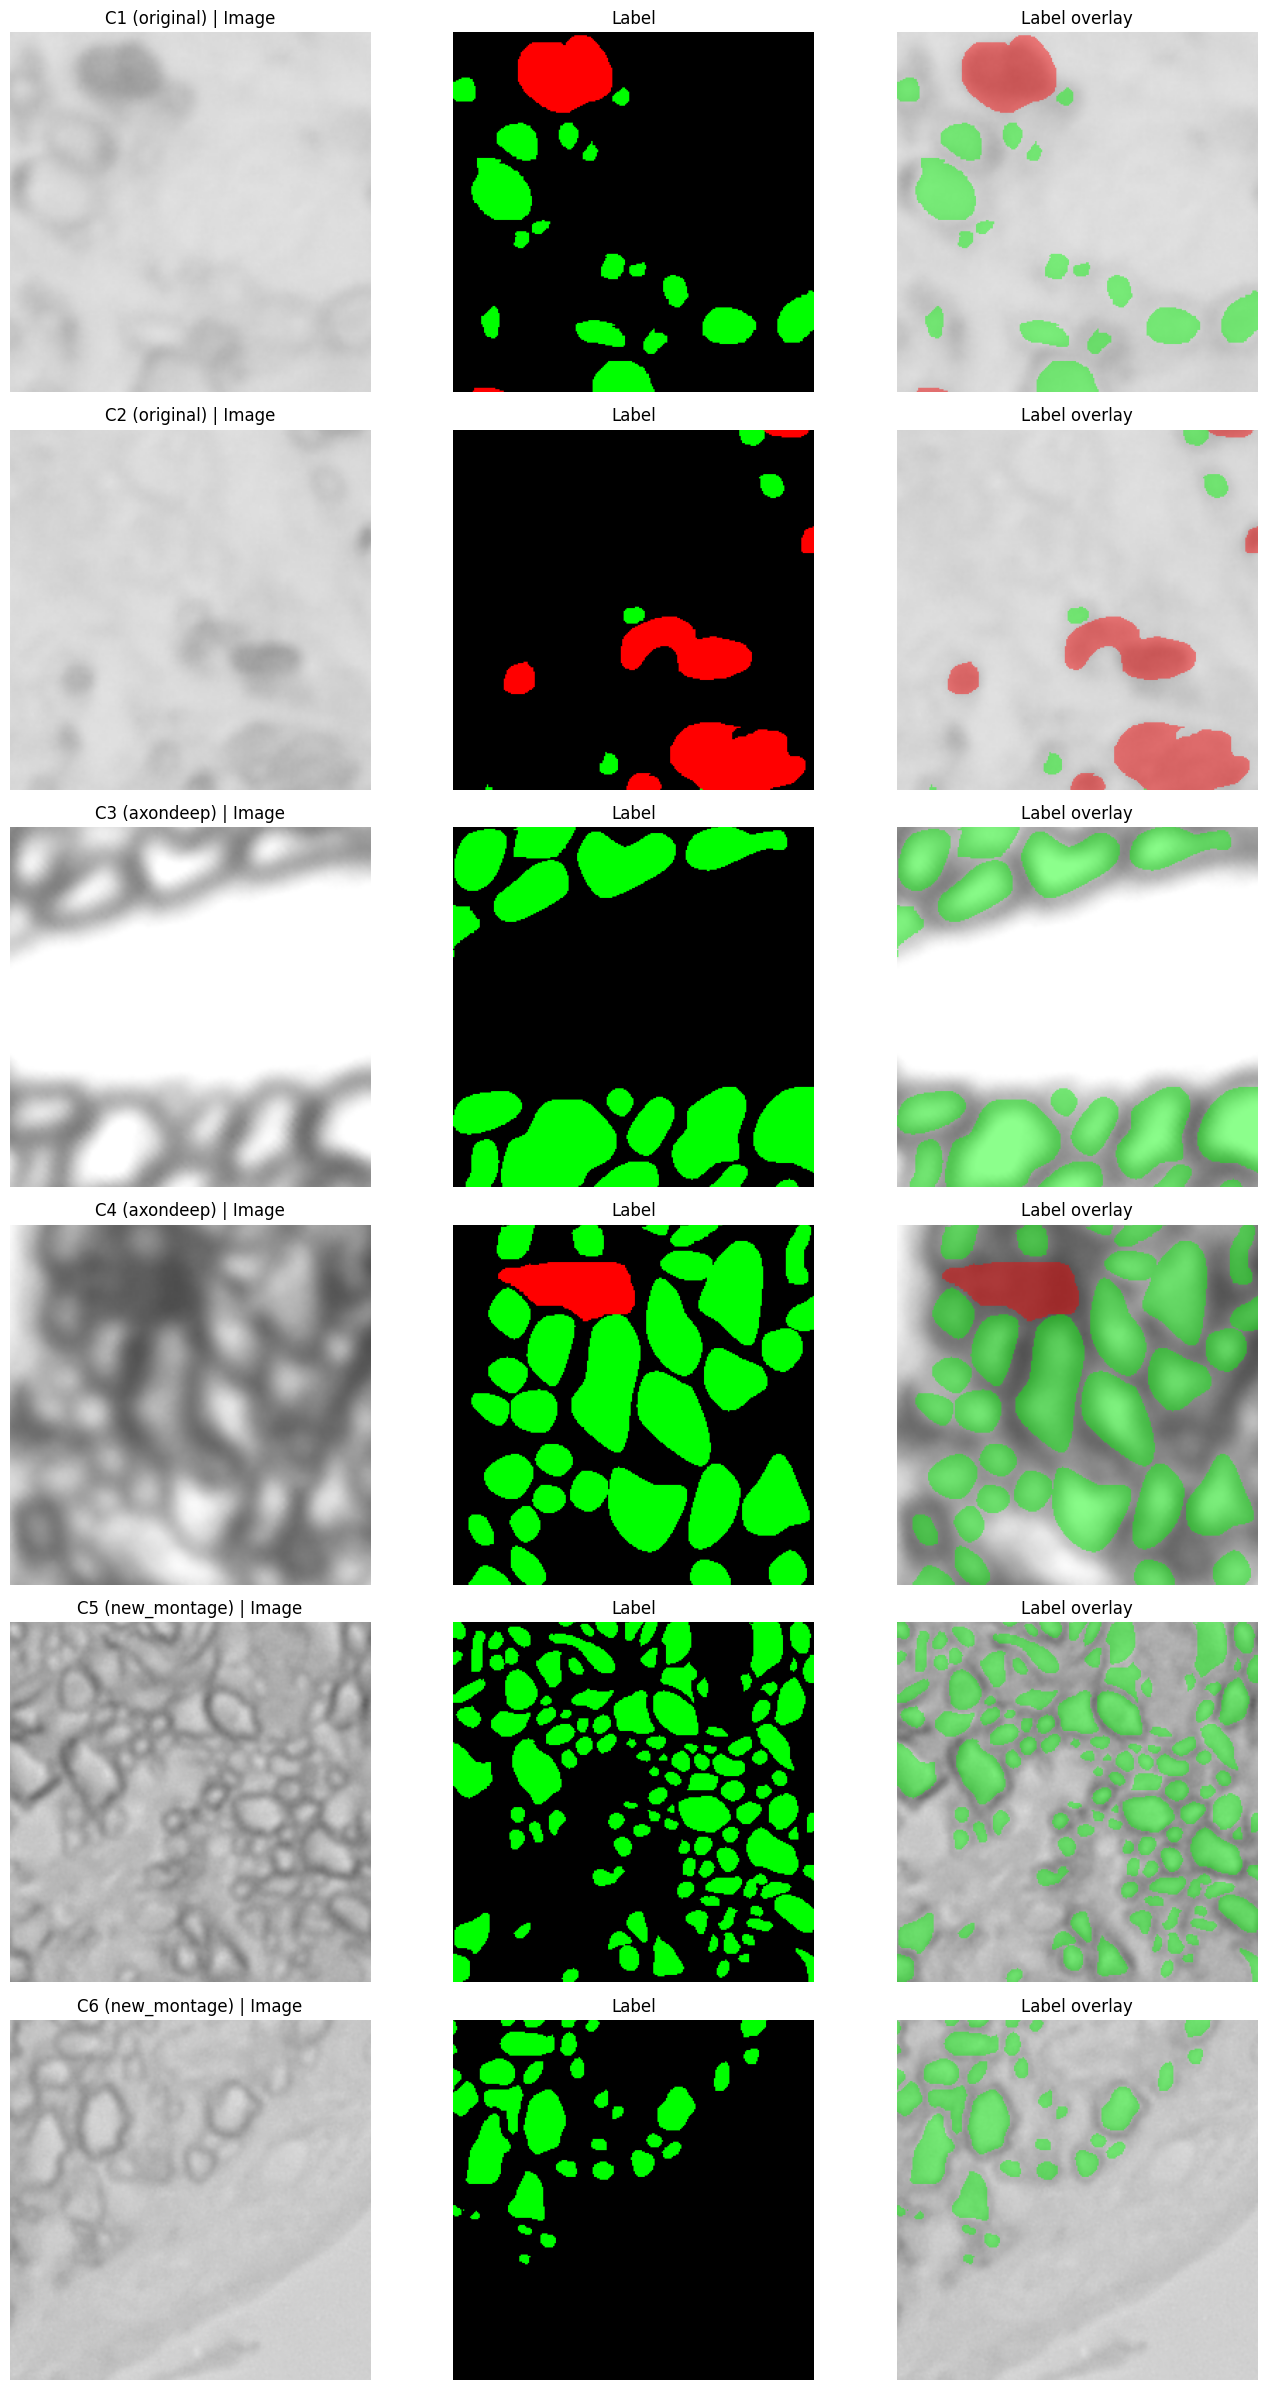

In [3]:
# ================================
# Cell 2.5: Show one example per client
# ================================
COLORS=np.array([[0,0,0],[0,255,0],[255,0,0]],np.uint8)
ALPHA=.45

fig,axs=plt.subplots(6,3,figsize=(14,24))

for r,cid in enumerate(CLIENT_DATA):
    d=CLIENT_DATA[cid]
    x=d["train"]["X"][0]
    y=d["train"]["Y"][0]

    img=np.clip(x.transpose(1,2,0),0,1)
    color=COLORS[y]/255.
    overlay=img.copy()
    m=y>0
    overlay[m]=(1-ALPHA)*img[m]+ALPHA*color[m]

    axs[r,0].imshow(img)
    axs[r,0].set_title(f"{cid} ({d['source']}) | Image")

    axs[r,1].imshow(color)
    axs[r,1].set_title("Label")

    axs[r,2].imshow(overlay)
    axs[r,2].set_title("Label overlay")

    for ax in axs[r]:ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
# ================================
# Cell 3: Offline augmentation + 6 client DataLoaders
# ================================
SEED=42
BATCH_SIZE=32
NUM_WORKERS=0
N_VIEWS=8  # 1 during evaluation
PIN_MEMORY=torch.cuda.is_available()

def seed_everything(seed=SEED):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
seed_everything()

def augment_uint8(x,y,c):
    if random.random()<.5:x,y,c=x[:,:,::-1],y[:,::-1],c[:,:,::-1]
    if random.random()<.5:x,y,c=x[:,::-1,:],y[::-1,:],c[:,::-1,:]
    k=random.randint(0,3)
    if k:x,y,c=np.rot90(x,k,(1,2)),np.rot90(y,k,(0,1)),np.rot90(c,k,(1,2))
    x,y,c=np.ascontiguousarray(x),np.ascontiguousarray(y),np.ascontiguousarray(c)
    xf=x.astype(np.float32)/255.
    if random.random()<.5:xf=np.clip(xf*random.uniform(.7,1.3),0,1)
    if random.random()<.5:xf=np.clip(xf+random.uniform(-.15,.15),0,1)
    if random.random()<.35:xf=np.power(np.clip(xf,0,1),random.uniform(1.,1.8))
    return (xf*255).round().astype(np.uint8),y,c

class AxonDataset(Dataset):
    def __init__(self,X,Y,C):
        self.X,self.Y,self.C=X,Y,C
        self.mean=torch.tensor(MEAN,dtype=torch.float32).view(3,1,1)
        self.std=torch.tensor(STD,dtype=torch.float32).view(3,1,1)
    def __len__(self):return len(self.X)
    def __getitem__(self,i):
        x=torch.from_numpy(self.X[i]).float().div_(255.)
        x=(x-self.mean)/(self.std+1e-6)
        y=torch.from_numpy(self.Y[i]).long()
        c=torch.from_numpy(self.C[i]).float()
        return x,y,c

CLIENT_LOADERS={}

for ci,(cid,d) in enumerate(CLIENT_DATA.items()):
    seed_everything(SEED+ci)
    X,Y,C=d["train"]["X"],d["train"]["Y"],d["train"]["C"]
    n=len(X)

    Xu=(np.clip(X,0,1)*255).round().astype(np.uint8)
    Yu=Y.astype(np.uint8);Cu=C.astype(np.uint8)

    Xa=np.empty((n*N_VIEWS,3,PATCH_SIZE,PATCH_SIZE),np.uint8)
    Ya=np.empty((n*N_VIEWS,PATCH_SIZE,PATCH_SIZE),np.uint8)
    Ca=np.empty((n*N_VIEWS,1,PATCH_SIZE,PATCH_SIZE),np.uint8)

    for i in tqdm(range(n),desc=f"Augmenting {cid}"):
        j=i*N_VIEWS
        Xa[j],Ya[j],Ca[j]=Xu[i],Yu[i],Cu[i]
        for v in range(1,N_VIEWS):
            Xa[j+v],Ya[j+v],Ca[j+v]=augment_uint8(Xu[i],Yu[i],Cu[i])

    Xv=(np.clip(d["val"]["X"],0,1)*255).round().astype(np.uint8)
    Yv=d["val"]["Y"].astype(np.uint8)
    Cv=d["val"]["C"].astype(np.uint8)

    train_ds=AxonDataset(Xa,Ya,Ca)
    val_ds=AxonDataset(Xv,Yv,Cv)
    train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,
                            pin_memory=PIN_MEMORY,drop_last=False) #drop_last=True
    val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)

    CLIENT_LOADERS[cid]={"train":train_loader,"val":val_loader,
                         "train_ds":train_ds,"val_ds":val_ds,"source":d["source"]}

    print(f"{cid} {d['source']:11s} | Train={len(train_ds):5d} ({len(train_loader):3d} batches) | "
          f"Val={len(val_ds):4d} ({len(val_loader):2d} batches)")

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:",DEVICE)

Augmenting C1:   0%|          | 0/1503 [00:00<?, ?it/s]

C1 original    | Train= 1503 ( 47 batches) | Val= 200 ( 7 batches)


Augmenting C2:   0%|          | 0/25 [00:00<?, ?it/s]

C2 original    | Train=   25 (  1 batches) | Val=  25 ( 1 batches)


Augmenting C3:   0%|          | 0/625 [00:00<?, ?it/s]

...

C4 axondeep    | Train=   25 (  1 batches) | Val=  25 ( 1 batches)


Augmenting C5:   0%|          | 0/607 [00:00<?, ?it/s]

C5 new_montage | Train=  607 ( 19 batches) | Val=  25 ( 1 batches)


Augmenting C6:   0%|          | 0/81 [00:00<?, ?it/s]

C6 new_montage | Train=   81 (  3 batches) | Val=  25 ( 1 batches)

Device: cuda


In [4]:
# ================================
# Cell 4: Model
# ================================
MODEL_NAME="nnunet_lite"

class DoubleConv(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.block=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False),
            nn.InstanceNorm2d(out_ch,affine=True),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False),
            nn.InstanceNorm2d(out_ch,affine=True),
            nn.LeakyReLU(inplace=True))
    def forward(self,x):return self.block(x)

class nnUNetLite(nn.Module):
    def __init__(self,in_ch=3,out_ch=3,filters=(32,64,128,256)):
        super().__init__()
        f1,f2,f3,f4=filters
        self.pool=nn.MaxPool2d(2)
        self.enc1=DoubleConv(in_ch,f1)
        self.enc2=DoubleConv(f1,f2)
        self.enc3=DoubleConv(f2,f3)
        self.bottleneck=DoubleConv(f3,f4)
        self.up3=nn.ConvTranspose2d(f4,f3,2,2);self.dec3=DoubleConv(f3*2,f3)
        self.up2=nn.ConvTranspose2d(f3,f2,2,2);self.dec2=DoubleConv(f2*2,f2)
        self.up1=nn.ConvTranspose2d(f2,f1,2,2);self.dec1=DoubleConv(f1*2,f1)
        self.head=nn.Conv2d(f1,out_ch,1)

    def forward(self,x):
        x1=self.enc1(x)
        x2=self.enc2(self.pool(x1))
        x3=self.enc3(self.pool(x2))
        x4=self.bottleneck(self.pool(x3))
        x=self.dec3(torch.cat([self.up3(x4),x3],1))
        x=self.dec2(torch.cat([self.up2(x),x2],1))
        x=self.dec1(torch.cat([self.up1(x),x1],1))
        return self.head(x)

def build_model(name):
    if name=="nnunet_lite":return nnUNetLite(3,NUM_CLASSES)
    raise ValueError(f"Unknown model: {name}")

model=build_model(MODEL_NAME).to(DEVICE)
n_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
with torch.no_grad():
    out=model(torch.zeros(1,3,512,512,device=DEVICE))
print(f"{MODEL_NAME}: {n_params:,} trainable parameters | output={tuple(out.shape)}")
del out
torch.cuda.empty_cache()

nnunet_lite: 1,927,075 trainable parameters | output=(1, 3, 512, 512)


In [9]:
# ================================
# Cell 5: Loss + metric + federated config
# ================================
ROUNDS=300
LOCAL_EPOCHS=1
GLOBAL_PATIENCE=30
LR=3e-4
WEIGHT_DECAY=1e-2
CE_WEIGHT=.5
DICE_WEIGHT=.5
CONTACT_ALPHA=2.
GRAD_CLIP=1.

SAVE_ROOT=Path("./outputs/nnunet_lite")
SAVE_ROOT.mkdir(parents=True,exist_ok=True)

def soft_dice_loss(logits,y,smooth=1.):
    p=torch.softmax(logits,1)
    t=F.one_hot(y,NUM_CLASSES).permute(0,3,1,2).float()
    inter=(p*t).sum((0,2,3))
    denom=(p+t).sum((0,2,3))
    dice=(2*inter+smooth)/(denom+smooth)
    return 1-dice[1:].mean()

def contact_ce_dice_loss(logits,y,contact):
    ce=F.cross_entropy(logits,y,reduction="none")
    w=1+CONTACT_ALPHA*contact[:,0]
    ce=(ce*w).sum()/w.sum()
    dice=soft_dice_loss(logits,y)
    return CE_WEIGHT*ce+DICE_WEIGHT*dice,ce,dice

@torch.no_grad()
def dice_scores(logits,y,smooth=1.):
    pred=logits.argmax(1)
    scores=[]
    for cls in range(1,NUM_CLASSES):
        p,t=pred==cls,y==cls
        scores.append(((2*(p&t).sum()+smooth)/(p.sum()+t.sum()+smooth)).item())
    return scores,sum(scores)/len(scores)

# Base patch counts for sample-weighted FedAvg
CLIENT_WEIGHTS={
    cid:len(CLIENT_DATA[cid]["train"]["X"])
    for cid in CLIENT_DATA
}
TOTAL_WEIGHT=sum(CLIENT_WEIGHTS.values())

print(f"FedAvg: {ROUNDS} rounds | {LOCAL_EPOCHS} local epoch/round | patience={GLOBAL_PATIENCE}")
print(f"Loss: {CE_WEIGHT} CE + {DICE_WEIGHT} Dice | contact weight={1+CONTACT_ALPHA:g}x")
print(f"AdamW: lr={LR:g}, weight_decay={WEIGHT_DECAY:g}")
print("FedAvg client weights:")
for cid,n in CLIENT_WEIGHTS.items():
    print(f"  {cid}: {n} patches ({100*n/TOTAL_WEIGHT:.1f}%)")
print("Checkpoint root:",SAVE_ROOT)

FedAvg: 300 rounds | 1 local epoch/round | patience=30
Loss: 0.5 CE + 0.5 Dice | contact weight=3x
AdamW: lr=0.0003, weight_decay=0.01
FedAvg client weights:
  C1: 1503 patches (52.4%)
  C2: 25 patches (0.9%)
  C3: 625 patches (21.8%)
  C4: 25 patches (0.9%)
  C5: 607 patches (21.2%)
  C6: 81 patches (2.8%)
Checkpoint root: C:\Users\Dhruba\Codes\saved_model_axon_federated\checkpoints\nnunet_lite


In [6]:
# ================================
# Cell 6: Federated training — weighted FedAvg
# ================================
def validate(model,loader):
    model.eval();loss_sum=0.;hi=hdn=di=ddn=0
    with torch.no_grad():
        for x,y,c in loader:
            x,y,c=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True),c.to(DEVICE,non_blocking=True)
            with autocast(enabled=DEVICE.type=="cuda"):
                logits=model(x);loss,_,_=contact_ce_dice_loss(logits,y,c)
            loss_sum+=loss.item()*x.size(0);pred=logits.argmax(1)
            for cls in (1,2):
                p,t=pred==cls,y==cls;inter=(p&t).sum().item();den=p.sum().item()+t.sum().item()
                if cls==1:hi+=inter;hdn+=den
                else:di+=inter;ddn+=den
    H=(2*hi+1)/(hdn+1);D=(2*di+1)/(ddn+1)
    return loss_sum/len(loader.dataset),H,D,(H+D)/2

def weighted_fedavg(states,weights):
    total=sum(weights);avg={}
    for k in states[0]:
        if states[0][k].is_floating_point():
            avg[k]=sum(s[k]*w for s,w in zip(states,weights))/total
        else:
            avg[k]=states[0][k]
    return avg

seed_everything(SEED)
global_model=build_model(MODEL_NAME).to(DEVICE)
global_state=copy.deepcopy(global_model.state_dict())

LOCAL_BEST={cid:-1. for cid in CLIENT_LOADERS}
LOCAL_HISTORY={cid:{"loss":[],"H":[],"D":[],"mean":[]} for cid in CLIENT_LOADERS}
GLOBAL_HISTORY={"round":[],"H":[],"D":[],"mean":[],"client_mean":{}}
best_global=-1.;bad_rounds=0

for rnd in range(1,ROUNDS+1):
    print(f"\n{'='*70}\nFederated round {rnd:03d}/{ROUNDS}\n{'='*70}")
    local_states=[];local_weights=[]

    # ---------- Local training ----------
    for cid,ld in CLIENT_LOADERS.items():
        model=build_model(MODEL_NAME).to(DEVICE)
        model.load_state_dict(global_state)
        optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
        scaler=GradScaler(enabled=DEVICE.type=="cuda")

        model.train();train_sum=0.
        pbar=tqdm(ld["train"],desc=f"Round {rnd:03d} | {cid} train",leave=False)
        for x,y,c in pbar:
            x,y,c=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True),c.to(DEVICE,non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=DEVICE.type=="cuda"):
                logits=model(x);loss,_,_=contact_ce_dice_loss(logits,y,c)
            scaler.scale(loss).backward();scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP)
            scaler.step(optimizer);scaler.update()
            train_sum+=loss.item()*x.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_loss,H,D,M=validate(model,ld["val"])
        LOCAL_HISTORY[cid]["loss"].append(val_loss)
        LOCAL_HISTORY[cid]["H"].append(H);LOCAL_HISTORY[cid]["D"].append(D);LOCAL_HISTORY[cid]["mean"].append(M)

        if M>LOCAL_BEST[cid]:
            LOCAL_BEST[cid]=M
            save_dir=SAVE_ROOT/cid;save_dir.mkdir(parents=True,exist_ok=True)
            torch.save({"model":model.state_dict(),"round":rnd,"best_dice":M,
                        "healthy_dice":H,"damaged_dice":D},save_dir/"best_dice.pt")
            flag=" ✅ local best"
        else:flag=""

        print(f"{cid} | train={train_sum/len(ld['train_ds']):.4f} | val={val_loss:.4f} | "
              f"H={H:.4f} | D={D:.4f} | mean={M:.4f}{flag}")

        local_states.append(copy.deepcopy(model.state_dict()))
        local_weights.append(CLIENT_WEIGHTS[cid])
        del model,optimizer,scaler
        torch.cuda.empty_cache()

    # ---------- Weighted FedAvg ----------
    global_state=weighted_fedavg(local_states,local_weights)
    global_model.load_state_dict(global_state)

    # ---------- Global validation on all clients ----------
    vals={}
    for cid,ld in CLIENT_LOADERS.items():
        vl,H,D,M=validate(global_model,ld["val"])
        vals[cid]={"loss":vl,"H":H,"D":D,"mean":M}

    gH=np.mean([v["H"] for v in vals.values()])
    gD=np.mean([v["D"] for v in vals.values()])
    gM=np.mean([v["mean"] for v in vals.values()])

    GLOBAL_HISTORY["round"].append(rnd)
    GLOBAL_HISTORY["H"].append(gH);GLOBAL_HISTORY["D"].append(gD);GLOBAL_HISTORY["mean"].append(gM)
    GLOBAL_HISTORY["client_mean"][rnd]={cid:v["mean"] for cid,v in vals.items()}

    print(f"\nGlobal | H={gH:.4f} | D={gD:.4f} | mean={gM:.4f}")
    print(" | ".join(f"{cid}={vals[cid]['mean']:.4f}" for cid in vals))

    if gM>best_global:
        best_global=gM;bad_rounds=0
        save_dir=SAVE_ROOT/"global";save_dir.mkdir(parents=True,exist_ok=True)
        torch.save({"model":global_state,"round":rnd,"best_dice":gM,
                    "healthy_dice":gH,"damaged_dice":gD,
                    "client_dice":{cid:v["mean"] for cid,v in vals.items()}},
                   save_dir/"best_dice.pt")
        print("✅ Global best saved")
    else:
        bad_rounds+=1
        print(f"No global improvement: {bad_rounds}/{GLOBAL_PATIENCE}")

    if bad_rounds>=GLOBAL_PATIENCE:
        print(f"\nEarly stopping at round {rnd}; best global mean Dice={best_global:.4f}")
        break

print("\nBest FL models")
for cid,v in LOCAL_BEST.items():print(f"{cid}: {v:.4f}")
print(f"Global: {best_global:.4f}")


Federated round 001/300


C:\Users\Dhruba\AppData\Local\Temp\ipykernel_27692\1233610734.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=DEVICE.type=="cuda")


Round 001 | C1 train:   0%|          | 0/376 [00:00<?, ?it/s]

C:\Users\Dhruba\AppData\Local\Temp\ipykernel_27692\1233610734.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=DEVICE.type=="cuda"):
C:\Users\Dhruba\AppData\Local\Temp\ipykernel_27692\1233610734.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=DEVICE.type=="cuda"):


C1 | train=0.5325 | val=0.3517 | H=0.7062 | D=0.7353 | mean=0.7208 ✅ local best


...

C4 | train=0.3053 | val=0.4858 | H=0.8166 | D=1.0000 | mean=0.9083


Round 074 | C5 train:   0%|          | 0/152 [00:00<?, ?it/s]

C5 | train=0.2089 | val=0.3351 | H=0.8587 | D=0.0618 | mean=0.4603


Round 074 | C6 train:   0%|          | 0/21 [00:00<?, ?it/s]

C6 | train=0.3572 | val=0.3568 | H=0.8557 | D=0.0001 | mean=0.4279

Global | H=0.8119 | D=0.4825 | mean=0.6472
C1=0.6616 | C2=0.7121 | C3=0.6413 | C4=0.9173 | C5=0.4755 | C6=0.4755
No global improvement: 30/30

Early stopping at round 74; best global mean Dice=0.6703

Best FL models
C1: 0.7674
C2: 0.8087
C3: 0.6696
C4: 0.9148
C5: 0.6587
C6: 0.4738
Global: 0.6703


C1 | best loss: round 15, 0.2432 | best Dice: round 12, mean=0.7674, H=0.7514, D=0.7835
C2 | best loss: round 29, 0.2592 | best Dice: round 42, mean=0.8087, H=0.8068, D=0.8107
C3 | best loss: round 33, 0.3738 | best Dice: round 33, mean=0.6696, H=0.8409, D=0.4983
C4 | best loss: round 50, 0.4595 | best Dice: round 50, mean=0.9148, H=0.8297, D=1.0000
C5 | best loss: round 18, 0.2425 | best Dice: round 18, mean=0.6587, H=0.8482, D=0.4693
C6 | best loss: round 22, 0.3306 | best Dice: round 22, mean=0.4738, H=0.8620, D=0.0856


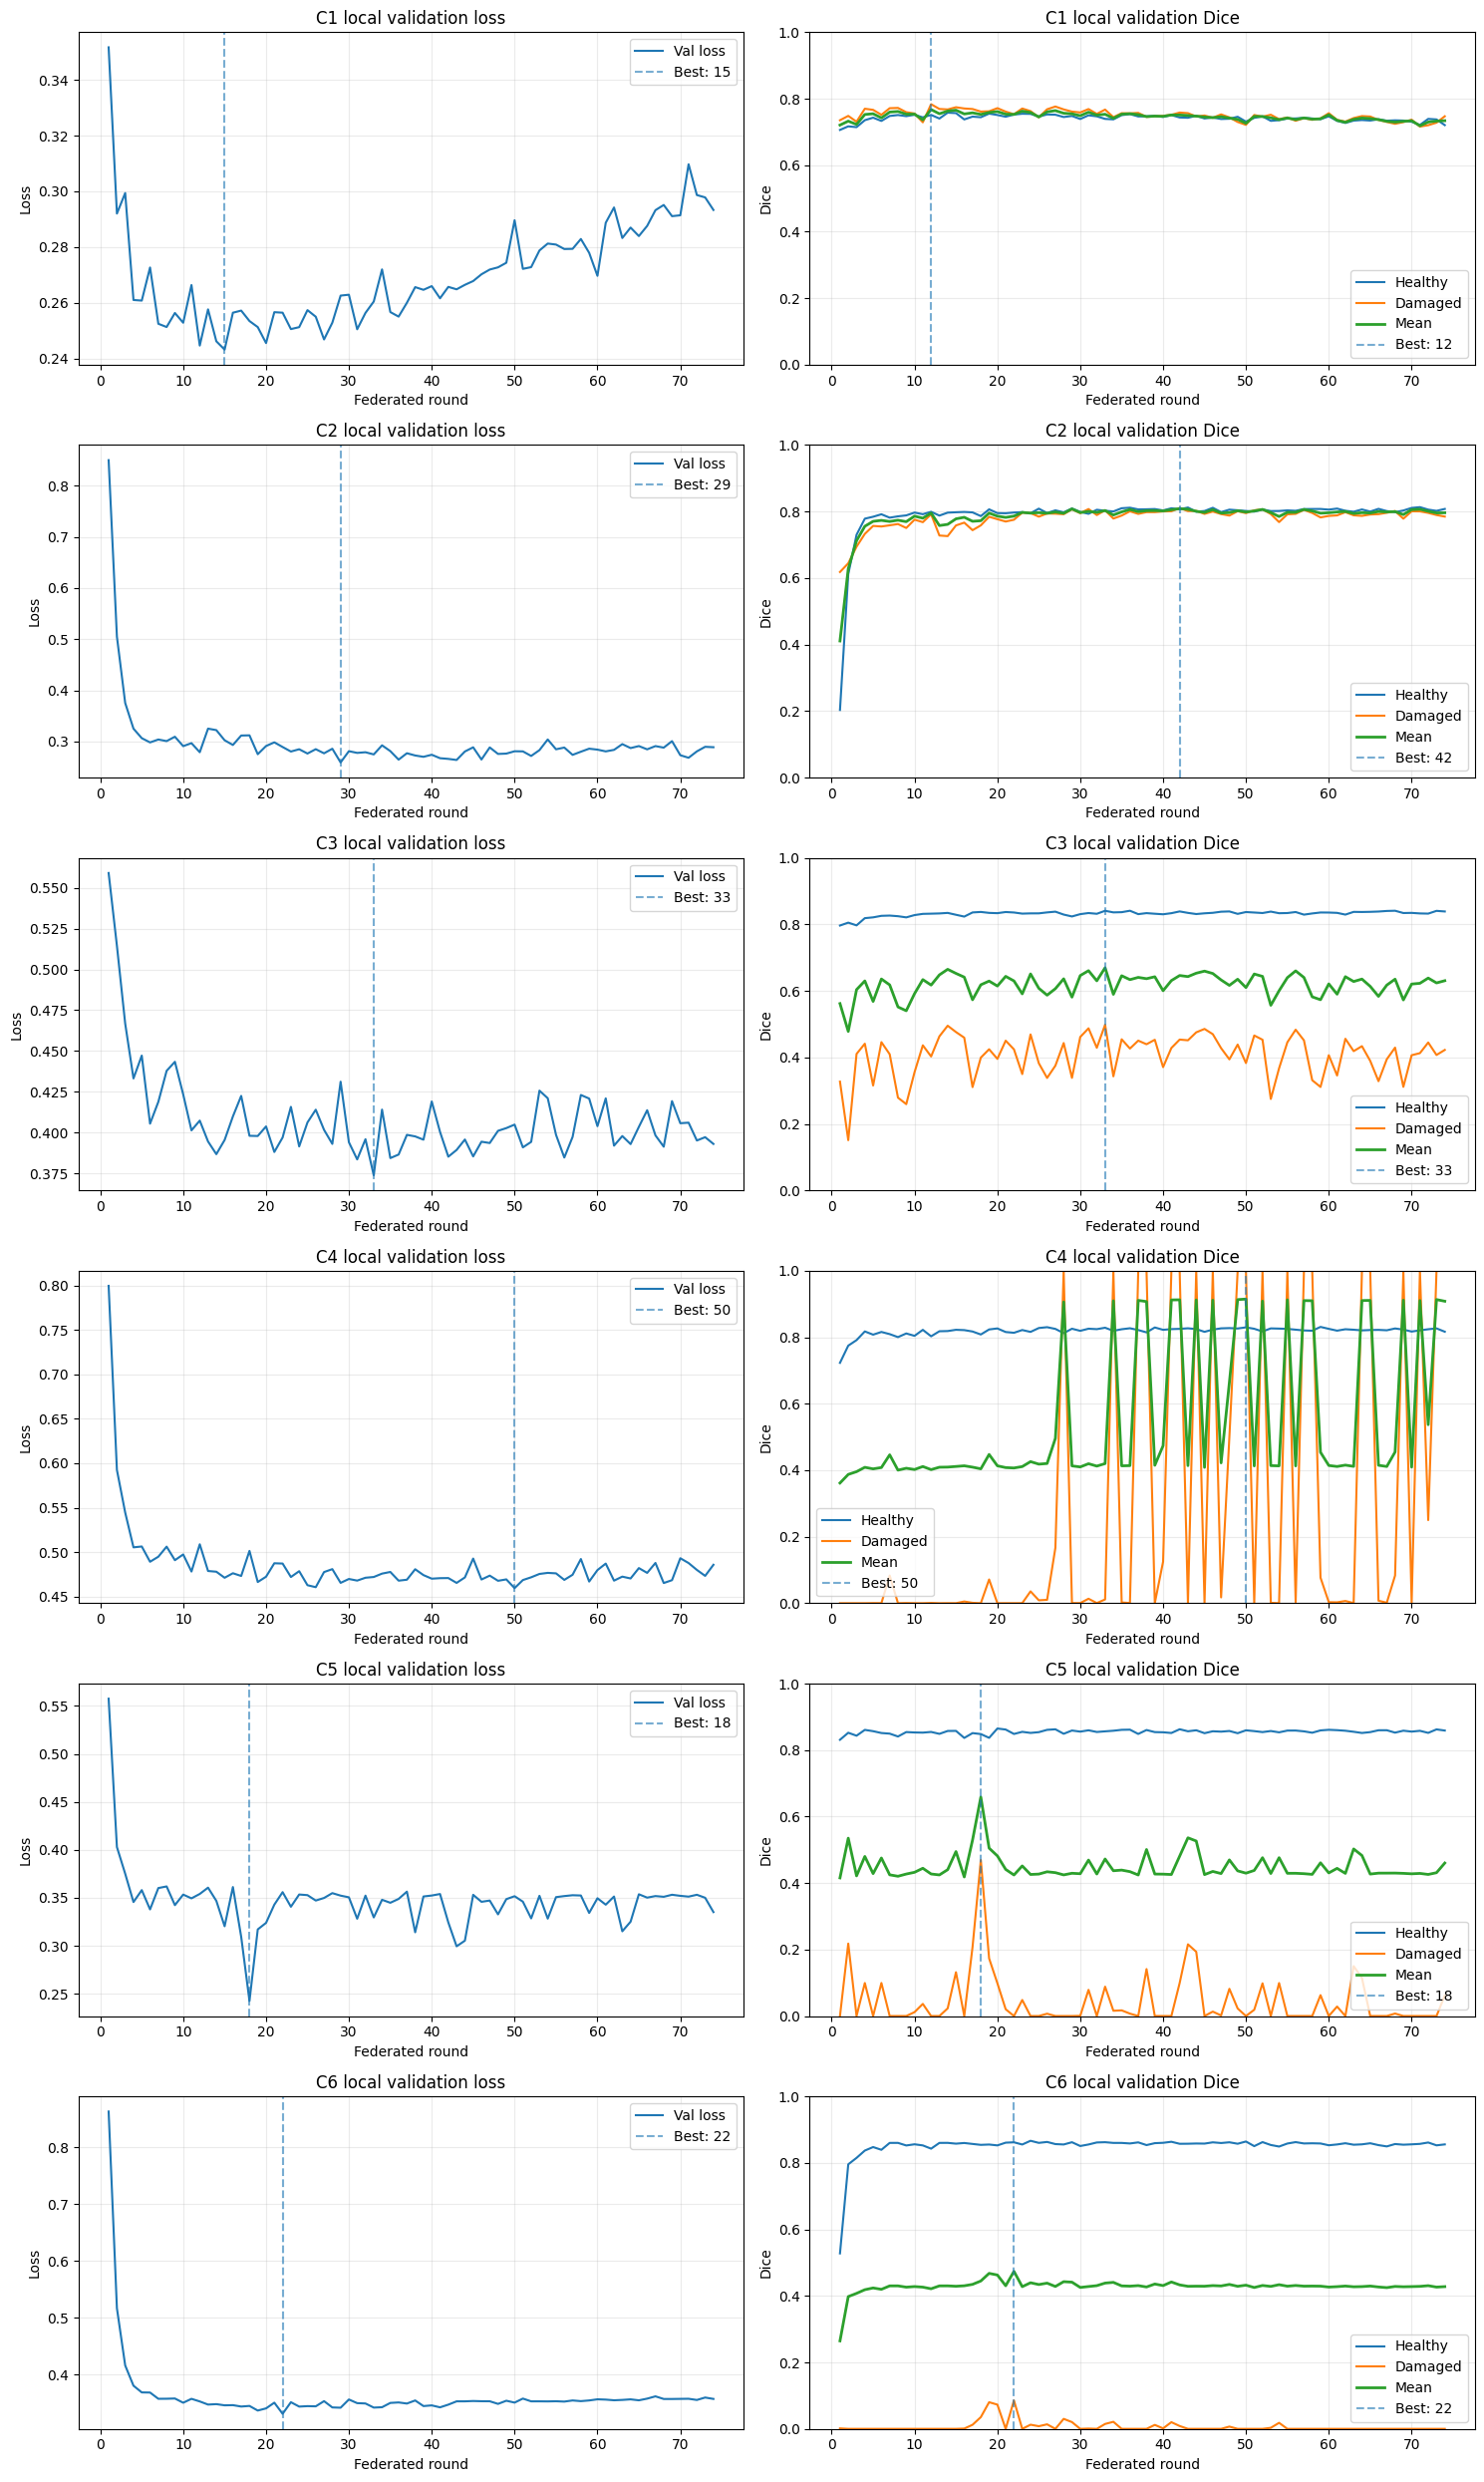

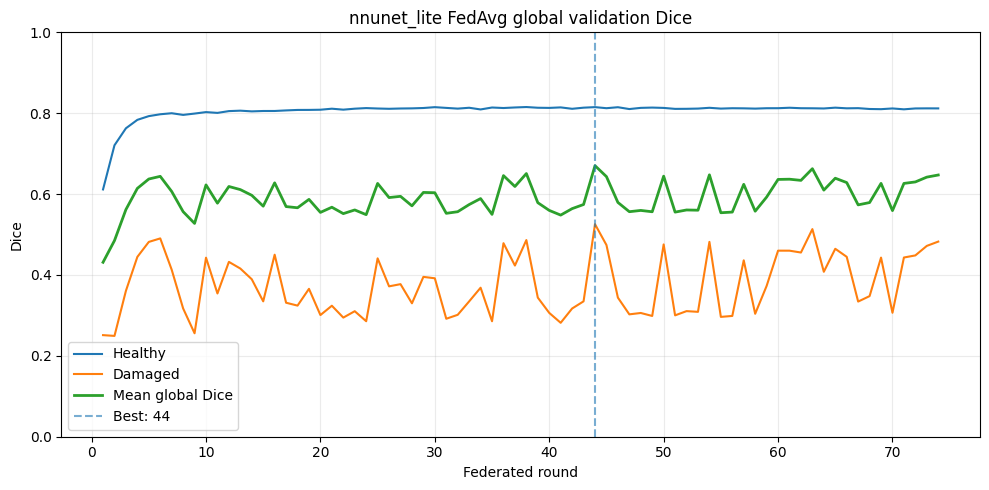


Best global Dice: round 44 | mean=0.6703 | H=0.8150 | D=0.5256


In [7]:
# ================================
# Cell 7: Plot federated training history
# ================================
fig,axs=plt.subplots(6,2,figsize=(15,25))

for r,(cid,h) in enumerate(LOCAL_HISTORY.items()):
    rounds=np.arange(1,len(h["loss"])+1)
    best_dice_round=int(np.argmax(h["mean"]))+1
    best_loss_round=int(np.argmin(h["loss"]))+1

    axs[r,0].plot(rounds,h["loss"],label="Val loss")
    axs[r,0].axvline(best_loss_round,ls="--",alpha=.6,label=f"Best: {best_loss_round}")
    axs[r,0].set(xlabel="Federated round",ylabel="Loss",title=f"{cid} local validation loss")
    axs[r,0].legend();axs[r,0].grid(alpha=.25)

    axs[r,1].plot(rounds,h["H"],label="Healthy")
    axs[r,1].plot(rounds,h["D"],label="Damaged")
    axs[r,1].plot(rounds,h["mean"],label="Mean",linewidth=2)
    axs[r,1].axvline(best_dice_round,ls="--",alpha=.6,label=f"Best: {best_dice_round}")
    axs[r,1].set(xlabel="Federated round",ylabel="Dice",title=f"{cid} local validation Dice",ylim=(0,1))
    axs[r,1].legend();axs[r,1].grid(alpha=.25)

    print(f"{cid} | best loss: round {best_loss_round}, {h['loss'][best_loss_round-1]:.4f} | "
          f"best Dice: round {best_dice_round}, mean={h['mean'][best_dice_round-1]:.4f}, "
          f"H={h['H'][best_dice_round-1]:.4f}, D={h['D'][best_dice_round-1]:.4f}")

plt.tight_layout()
plt.show()

# ---------- Global model history ----------
rounds=np.array(GLOBAL_HISTORY["round"])
best_global_round=int(np.argmax(GLOBAL_HISTORY["mean"]))
best_round_num=rounds[best_global_round]

plt.figure(figsize=(10,5))
plt.plot(rounds,GLOBAL_HISTORY["H"],label="Healthy")
plt.plot(rounds,GLOBAL_HISTORY["D"],label="Damaged")
plt.plot(rounds,GLOBAL_HISTORY["mean"],label="Mean global Dice",linewidth=2)
plt.axvline(best_round_num,ls="--",alpha=.6,label=f"Best: {best_round_num}")
plt.xlabel("Federated round");plt.ylabel("Dice")
plt.title(f"{MODEL_NAME} FedAvg global validation Dice")
plt.ylim(0,1);plt.grid(alpha=.25);plt.legend()
plt.tight_layout();plt.show()

print(f"\nBest global Dice: round {best_round_num} | "
      f"mean={GLOBAL_HISTORY['mean'][best_global_round]:.4f} | "
      f"H={GLOBAL_HISTORY['H'][best_global_round]:.4f} | "
      f"D={GLOBAL_HISTORY['D'][best_global_round]:.4f}")

In [10]:
# ================================
# Cell 8: Evaluate 6 local + global FL models on all test sets
# ================================
TEST_OVERLAP=128
TEST_STRIDE=PATCH_SIZE-TEST_OVERLAP
INFER_BATCH=8

g1=cv2.getGaussianKernel(PATCH_SIZE,PATCH_SIZE/8)
GAUSS=(g1@g1.T).astype(np.float32)
GAUSS=np.maximum(GAUSS,GAUSS.max()*1e-3)

mean_t=torch.tensor(MEAN,dtype=torch.float32,device=DEVICE).view(1,3,1,1)
std_t=torch.tensor(STD,dtype=torch.float32,device=DEVICE).view(1,3,1,1)

def positions(n):
    if n<=PATCH_SIZE:return [0]
    p=list(range(0,n-PATCH_SIZE+1,TEST_STRIDE))
    if p[-1]!=n-PATCH_SIZE:p.append(n-PATCH_SIZE)
    return p

@torch.inference_mode()
def predict_full(x):
    _,h,w=x.shape
    ph=max(PATCH_SIZE-h,0);pw=max(PATCH_SIZE-w,0)
    if ph or pw:x=np.pad(x,((0,0),(0,ph),(0,pw)),mode="reflect")
    _,H,W=x.shape
    coords=[(y,x0) for y in positions(H) for x0 in positions(W)]
    prob=np.zeros((NUM_CLASSES,H,W),np.float32)
    weight=np.zeros((H,W),np.float32)

    for k in range(0,len(coords),INFER_BATCH):
        bc=coords[k:k+INFER_BATCH]
        batch=np.stack([x[:,y:y+PATCH_SIZE,x0:x0+PATCH_SIZE] for y,x0 in bc])
        batch=torch.from_numpy(batch).float().to(DEVICE)
        batch=(batch-mean_t)/(std_t+1e-6)

        with torch.amp.autocast("cuda",enabled=DEVICE.type=="cuda"):
            out=torch.softmax(model(batch),1).float().cpu().numpy()

        for p,(y,x0) in zip(out,bc):
            prob[:,y:y+PATCH_SIZE,x0:x0+PATCH_SIZE]+=p*GAUSS
            weight[y:y+PATCH_SIZE,x0:x0+PATCH_SIZE]+=GAUSS

    return (prob/np.maximum(weight,1e-8))[...,:h,:w].argmax(0).astype(np.uint8)

def binary_dice(pred,gt,cls):
    p,g=pred==cls,gt==cls
    den=p.sum()+g.sum()
    return np.nan if den==0 else 2*(p&g).sum()/den

# ---------- 6 local best + 1 global best ----------
EVAL_MODELS={cid:SAVE_ROOT/cid/"best_dice.pt" for cid in CLIENT_LOADERS}
EVAL_MODELS["GLOBAL"]=SAVE_ROOT/"global"/"best_dice.pt"

rows=[]

for mid,ckpt_path in EVAL_MODELS.items():
    ckpt=torch.load(ckpt_path,map_location=DEVICE,weights_only=False)

    model=build_model(MODEL_NAME).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()

    rnd=ckpt.get("round","?")
    best=ckpt.get("best_dice",np.nan)
    train_source=CLIENT_LOADERS[mid]["source"] if mid!="GLOBAL" else "FedAvg"

    print(f"\n{'='*65}")
    print(f"{mid} | {train_source} | best round={rnd} | val Dice={best:.4f}")
    print("="*65)

    for source,ds in TEST_SETS.items():
        for x,y,name in tqdm(zip(ds["images"],ds["labels"],ds["names"]),
                             total=len(ds["images"]),
                             desc=f"{mid} → {source}",leave=False):

            pred=predict_full(x)
            hd=binary_dice(pred,y,1)
            dd=binary_dice(pred,y,2)

            hp=int((y==1).sum())
            dp=int((y==2).sum())
            wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

            rows.append({
                "model":mid,
                "train_source":train_source,
                "dataset":source,
                "image":name,
                "healthy_dice":hd,
                "damaged_dice":dd,
                "healthy_pixels":hp,
                "damaged_pixels":dp,
                "weighted_dice":wd
            })

    del model
    torch.cuda.empty_cache()

test_df=pd.DataFrame(rows)

# ---------- Per-dataset summary ----------
summary=test_df.groupby(["model","train_source","dataset"]).agg(
    n_images=("image","size"),
    healthy_dice=("healthy_dice","mean"),
    damaged_dice=("damaged_dice","mean"),
    healthy_pixels=("healthy_pixels","sum"),
    damaged_pixels=("damaged_pixels","sum"),
    weighted_dice=("weighted_dice","mean")
).reset_index()

# ---------- Combined 3-test-set summary for each model ----------
combined_rows=[]

for mid in EVAL_MODELS:
    sub=test_df[test_df["model"]==mid]

    h_mean=sub["healthy_dice"].mean()
    d_mean=sub["damaged_dice"].mean()

    hp=int(sub["healthy_pixels"].sum())
    dp=int(sub["damaged_pixels"].sum())

    wd=(h_mean*hp+d_mean*dp)/(hp+dp)

    combined_rows.append({
        "model":mid,
        "train_source":"FedAvg" if mid=="GLOBAL" else CLIENT_LOADERS[mid]["source"],
        "dataset":"combined",
        "n_images":len(sub),
        "healthy_dice":h_mean,
        "damaged_dice":d_mean,
        "healthy_pixels":hp,
        "damaged_pixels":dp,
        "weighted_dice":wd
    })

combined_df=pd.DataFrame(combined_rows)

summary=pd.concat([summary,combined_df],ignore_index=True)

# ---------- Print results ----------
for mid in EVAL_MODELS:
    label="FedAvg" if mid=="GLOBAL" else CLIENT_LOADERS[mid]["source"]

    print(f"\n{mid} ({label})")

    for _,r in summary[summary["model"]==mid].iterrows():
        print(f"{r['dataset']:12s} | n={int(r['n_images']):2d} | "
              f"H={r['healthy_dice']:.4f} | "
              f"D={r['damaged_dice']:.4f} | "
              f"Weighted={r['weighted_dice']:.4f}")

display(summary.round(4))


C1 | original | best round=28 | val Dice=0.7645


C1 → original:   0%|          | 0/18 [00:00<?, ?it/s]

C1 → axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

C1 → new_montage:   0%|          | 0/1 [00:00<?, ?it/s]


C2 | original | best round=25 | val Dice=0.7799


...

GLOBAL → original:   0%|          | 0/18 [00:00<?, ?it/s]

GLOBAL → axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

GLOBAL → new_montage:   0%|          | 0/1 [00:00<?, ?it/s]


C1 (original)
axondeep     | n=18 | H=0.6735 | D=0.1249 | Weighted=0.6648
new_montage  | n= 1 | H=0.8261 | D=0.5971 | Weighted=0.8237
original     | n=18 | H=0.7302 | D=0.7663 | Weighted=0.7528
combined     | n=37 | H=0.7052 | D=0.4497 | Weighted=0.6706

C2 (original)
axondeep     | n=18 | H=0.7569 | D=0.2389 | Weighted=0.7525
new_montage  | n= 1 | H=0.8057 | D=0.6885 | Weighted=0.8045
original     | n=18 | H=0.7236 | D=0.7745 | Weighted=0.7532
combined     | n=37 | H=0.7421 | D=0.5116 | Weighted=0.7109

C3 (axondeep)
axondeep     | n=18 | H=0.8293 | D=0.2959 | Weighted=0.8214
new_montage  | n= 1 | H=0.7471 | D=0.3236 | Weighted=0.7427
original     | n=18 | H=0.6265 | D=0.4086 | Weighted=0.5296
combined     | n=37 | H=0.7284 | D=0.3515 | Weighted=0.6774

C4 (axondeep)
axondeep     | n=18 | H=0.8679 | D=0.4183 | Weighted=0.8620
new_montage  | n= 1 | H=0.8392 | D=0.0048 | Weighted=0.8305
original     | n=18 | H=0.6592 | D=0.4926 | Weighted=0.5887
combined     | n=37 | H=0.7656 | D=0.443

,model,train_source,dataset,n_images,healthy_dice,damaged_dice,healthy_pixels,damaged_pixels,weighted_dice
0,C1,original,axondeep,18,0.6735,0.1249,31689376,1084648,0.6648
1,C1,original,new_montage,1,0.8261,0.5971,664232,7000,0.8237
2,C1,original,original,18,0.7302,0.7663,5420024,4822408,0.7528
3,C2,original,axondeep,18,0.7569,0.2389,31689376,1084648,0.7525
4,C2,original,new_montage,1,0.8057,0.6885,664232,7000,0.8045
5,C2,original,original,18,0.7236,0.7745,5420024,4822408,0.7532
6,C3,axondeep,axondeep,18,0.8293,0.2959,31689376,1084648,0.8214
7,C3,axondeep,new_montage,1,0.7471,0.3236,664232,7000,0.7427
8,C3,axondeep,original,18,0.6265,0.4086,5420024,4822408,0.5296
9,C4,axondeep,axondeep,18,0.8679,0.4183,31689376,1084648,0.8620


In [11]:
# ================================
# Cell 9: FL local + global noise removal + thin-bridge post-processing
# ================================
HEALTHY_MIN_AREA=100
DAMAGED_MIN_AREA=200
MIN_SPLIT_AREA=50
MIN_CORE_AREA=12
MIN_FINAL_AREA=20
MAX_EROSIONS=4
MAX_AREA_RATIO=4.
CUT_WIDTH=1
STRUCT=np.ones((3,3),bool)

def remove_small(mask,min_area):
    n,lab,stats,_=cv2.connectedComponentsWithStats(mask.astype(np.uint8),8)
    out=np.zeros_like(mask,dtype=np.uint8)
    for i in range(1,n):
        if stats[i,cv2.CC_STAT_AREA]>=min_area:out[lab==i]=1
    return out

def keep_largest(mask):
    lab,n=ndi.label(mask,structure=STRUCT)
    if not n:return np.zeros_like(mask,bool)
    sizes=ndi.sum(np.ones_like(mask),lab,range(1,n+1))
    return lab==(np.argmax(sizes)+1)

def split_thin_bridges(mask):
    mask=mask.astype(np.uint8)
    n,lab,stats,_=cv2.connectedComponentsWithStats(mask,8)
    out=np.zeros_like(mask);gap_all=np.zeros_like(mask,bool)
    splits=0
    pad=MAX_EROSIONS+CUT_WIDTH+2

    for cid in range(1,n):
        x,y,w,h,area=stats[cid]
        if area<MIN_SPLIT_AREA:
            out[lab==cid]=1;continue

        x0=max(0,x-pad);y0=max(0,y-pad)
        x1=min(mask.shape[1],x+w+pad);y1=min(mask.shape[0],y+h+pad)
        comp=(lab[y0:y1,x0:x1]==cid)
        cores=None

        for it in range(1,MAX_EROSIONS+1):
            er=ndi.binary_erosion(comp,STRUCT,iterations=it)
            en,el,estats,_=cv2.connectedComponentsWithStats(er.astype(np.uint8),8)
            ids=[j for j in range(1,en) if estats[j,cv2.CC_STAT_AREA]>=MIN_CORE_AREA]
            if len(ids)==2:
                a1,a2=estats[ids[0],cv2.CC_STAT_AREA],estats[ids[1],cv2.CC_STAT_AREA]
                if max(a1,a2)/max(min(a1,a2),1)<=MAX_AREA_RATIO:
                    cores=[el==ids[0],el==ids[1]];break

        roi=out[y0:y1,x0:x1]
        if cores is None:
            roi[comp]=1;continue

        d1=ndi.distance_transform_edt(~cores[0])
        d2=ndi.distance_transform_edt(~cores[1])
        p1=comp&(d1<=d2);p2=comp&(d2<d1)

        if min(p1.sum(),p2.sum())<MIN_FINAL_AREA or max(p1.sum(),p2.sum())/max(min(p1.sum(),p2.sum()),1)>MAX_AREA_RATIO:
            roi[comp]=1;continue

        cut=(p1&ndi.binary_dilation(p2,STRUCT))|(p2&ndi.binary_dilation(p1,STRUCT))
        if CUT_WIDTH>1:cut=ndi.binary_dilation(cut,STRUCT,iterations=CUT_WIDTH-1)&comp
        p1=keep_largest(p1&~cut);p2=keep_largest(p2&~cut)

        if min(p1.sum(),p2.sum())<MIN_FINAL_AREA or max(p1.sum(),p2.sum())/max(min(p1.sum(),p2.sum()),1)>MAX_AREA_RATIO:
            roi[comp]=1;continue

        roi[p1|p2]=1
        gap_all[y0:y1,x0:x1]|=cut
        splits+=1

    return out,gap_all,splits

def postprocess_semantic(pred):
    h=remove_small(pred==1,HEALTHY_MIN_AREA)
    d=remove_small(pred==2,DAMAGED_MIN_AREA)
    h,hgap,hs=split_thin_bridges(h)
    d,dgap,ds=split_thin_bridges(d)
    out=np.zeros_like(pred,np.uint8)
    out[h>0]=1;out[d>0]=2
    return out,hgap|dgap,hs,ds

EVAL_MODELS={cid:SAVE_ROOT/cid/"best_dice.pt" for cid in CLIENT_LOADERS}
EVAL_MODELS["GLOBAL"]=SAVE_ROOT/"global"/"best_dice.pt"

POST_MODEL_TEST_SETS={}
rows=[]

for mid,ckpt_path in EVAL_MODELS.items():
    ckpt=torch.load(ckpt_path,map_location=DEVICE,weights_only=False)
    model=build_model(MODEL_NAME).to(DEVICE)
    model.load_state_dict(ckpt["model"]);model.eval()

    train_source=CLIENT_LOADERS[mid]["source"] if mid!="GLOBAL" else "FedAvg"
    POST_MODEL_TEST_SETS[mid]={}

    for source,ds in TEST_SETS.items():
        preds_raw,preds_post=[],[]

        for x,y,name in tqdm(zip(ds["images"],ds["labels"],ds["names"]),
                             total=len(ds["images"]),desc=f"{mid} post {source}"):

            raw=predict_full(x)
            post,gap,hs,dsplits=postprocess_semantic(raw)

            hd=binary_dice(post,y,1)
            dd=binary_dice(post,y,2)
            hp,dp=int((y==1).sum()),int((y==2).sum())
            wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

            rows.append({
                "model":mid,
                "train_source":train_source,
                "dataset":source,
                "image":name,
                "healthy_dice":hd,
                "damaged_dice":dd,
                "healthy_pixels":hp,
                "damaged_pixels":dp,
                "weighted_dice":wd,
                "healthy_splits":hs,
                "damaged_splits":dsplits,
                "removed_gap_pixels":int(gap.sum())
            })

            preds_raw.append(raw)
            preds_post.append(post)

        POST_MODEL_TEST_SETS[mid][source]={"raw":preds_raw,"post":preds_post}

    del model
    torch.cuda.empty_cache()

post_df=pd.DataFrame(rows)

# ---------- Per-dataset summary ----------
summary=post_df.groupby(["model","train_source","dataset"]).agg(
    n_images=("image","size"),
    healthy_dice=("healthy_dice","mean"),
    damaged_dice=("damaged_dice","mean"),
    healthy_pixels=("healthy_pixels","sum"),
    damaged_pixels=("damaged_pixels","sum"),
    weighted_dice=("weighted_dice","mean"),
    healthy_splits=("healthy_splits","sum"),
    damaged_splits=("damaged_splits","sum"),
    removed_gap_pixels=("removed_gap_pixels","sum")
).reset_index()

# ---------- Combined 3-test-set summary ----------
combined_rows=[]

for mid in EVAL_MODELS:
    sub=post_df[post_df["model"]==mid]

    h_mean=sub["healthy_dice"].mean()
    d_mean=sub["damaged_dice"].mean()
    hp=int(sub["healthy_pixels"].sum())
    dp=int(sub["damaged_pixels"].sum())

    wd=(h_mean*hp+d_mean*dp)/(hp+dp)

    combined_rows.append({
        "model":mid,
        "train_source":"FedAvg" if mid=="GLOBAL" else CLIENT_LOADERS[mid]["source"],
        "dataset":"combined",
        "n_images":len(sub),
        "healthy_dice":h_mean,
        "damaged_dice":d_mean,
        "healthy_pixels":hp,
        "damaged_pixels":dp,
        "weighted_dice":wd,
        "healthy_splits":int(sub["healthy_splits"].sum()),
        "damaged_splits":int(sub["damaged_splits"].sum()),
        "removed_gap_pixels":int(sub["removed_gap_pixels"].sum())
    })

combined_df=pd.DataFrame(combined_rows)
summary=pd.concat([summary,combined_df],ignore_index=True)

# ---------- Print ----------
for mid in EVAL_MODELS:
    label=CLIENT_LOADERS[mid]["source"] if mid!="GLOBAL" else "FedAvg"

    print(f"\n{mid} ({label})")

    for _,r in summary[summary["model"]==mid].iterrows():
        print(f"{r['dataset']:12s} | n={int(r['n_images']):2d} | "
              f"H={r['healthy_dice']:.4f} | D={r['damaged_dice']:.4f} | "
              f"Weighted={r['weighted_dice']:.4f} | "
              f"H splits={int(r['healthy_splits'])} | "
              f"D splits={int(r['damaged_splits'])}")

display(summary.round(4))

C1 post original:   0%|          | 0/18 [00:00<?, ?it/s]

C1 post axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

C1 post new_montage:   0%|          | 0/1 [00:00<?, ?it/s]

C2 post original:   0%|          | 0/18 [00:00<?, ?it/s]

C2 post axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

...

GLOBAL post original:   0%|          | 0/18 [00:00<?, ?it/s]

GLOBAL post axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

GLOBAL post new_montage:   0%|          | 0/1 [00:00<?, ?it/s]


C1 (original)
axondeep     | n=18 | H=0.6721 | D=0.1265 | Weighted=0.6636 | H splits=358 | D splits=247
new_montage  | n= 1 | H=0.8260 | D=0.6409 | Weighted=0.8241 | H splits=15 | D splits=1
original     | n=18 | H=0.7308 | D=0.7680 | Weighted=0.7539 | H splits=93 | D splits=42
combined     | n=37 | H=0.7048 | D=0.4525 | Weighted=0.6707 | H splits=466 | D splits=290

C2 (original)
axondeep     | n=18 | H=0.7556 | D=0.2423 | Weighted=0.7514 | H splits=387 | D splits=66
new_montage  | n= 1 | H=0.8052 | D=0.6838 | Weighted=0.8040 | H splits=7 | D splits=0
original     | n=18 | H=0.7239 | D=0.7757 | Weighted=0.7538 | H splits=67 | D splits=39
combined     | n=37 | H=0.7415 | D=0.5137 | Weighted=0.7107 | H splits=461 | D splits=105

C3 (axondeep)
axondeep     | n=18 | H=0.8292 | D=0.3012 | Weighted=0.8214 | H splits=249 | D splits=26
new_montage  | n= 1 | H=0.7501 | D=0.3339 | Weighted=0.7458 | H splits=28 | D splits=0
original     | n=18 | H=0.6283 | D=0.4050 | Weighted=0.5288 | H splits=

,model,train_source,dataset,n_images,healthy_dice,damaged_dice,healthy_pixels,damaged_pixels,weighted_dice,healthy_splits,damaged_splits,removed_gap_pixels
0,C1,original,axondeep,18,0.6721,0.1265,31689376,1084648,0.6636,358,247,12052
1,C1,original,new_montage,1,0.8260,0.6409,664232,7000,0.8241,15,1,307
2,C1,original,original,18,0.7308,0.7680,5420024,4822408,0.7539,93,42,2585
3,C2,original,axondeep,18,0.7556,0.2423,31689376,1084648,0.7514,387,66,9683
4,C2,original,new_montage,1,0.8052,0.6838,664232,7000,0.8040,7,0,133
5,C2,original,original,18,0.7239,0.7757,5420024,4822408,0.7538,67,39,1998
6,C3,axondeep,axondeep,18,0.8292,0.3012,31689376,1084648,0.8214,249,26,5213
7,C3,axondeep,new_montage,1,0.7501,0.3339,664232,7000,0.7458,28,0,492
8,C3,axondeep,original,18,0.6283,0.4050,5420024,4822408,0.5288,149,25,2966
9,C4,axondeep,axondeep,18,0.8680,0.4449,31689376,1084648,0.8599,360,8,8383


In [12]:
# ================================
# Cell 10: FL local + global axon count + instance matching
# ================================
COVERAGE_THR=.33

def label_instances(mask):
    n,lab=cv2.connectedComponents(mask.astype(np.uint8),8)
    return lab,n-1

def match_instances(gt_mask,pred_mask,thr=COVERAGE_THR):
    gt,ng=label_instances(gt_mask)
    pr,npred=label_instances(pred_mask)
    if ng==0:return {"gt":0,"pred":npred,"tp":0,"fp":npred,"fn":0}
    if npred==0:return {"gt":ng,"pred":0,"tp":0,"fp":0,"fn":ng}

    gt_area=np.bincount(gt.ravel(),minlength=ng+1)[1:]
    pairs=[]
    overlap=(gt>0)&(pr>0)

    if overlap.any():
        ids=np.stack([gt[overlap],pr[overlap]],1)
        unique,count=np.unique(ids,axis=0,return_counts=True)
        for (g,p),inter in zip(unique,count):
            coverage=inter/gt_area[g-1]
            if coverage>=thr:pairs.append((coverage,int(inter),int(g),int(p)))

    pairs.sort(reverse=True)
    used_g,used_p=set(),set()

    for coverage,inter,g,p in pairs:
        if g not in used_g and p not in used_p:
            used_g.add(g);used_p.add(p)

    tp=len(used_g)
    return {"gt":ng,"pred":npred,"tp":tp,"fp":npred-tp,"fn":ng-tp}

rows=[]

EVAL_MODELS=list(CLIENT_LOADERS.keys())+["GLOBAL"]

for mid in EVAL_MODELS:
    train_source=CLIENT_LOADERS[mid]["source"] if mid!="GLOBAL" else "FedAvg"

    for source,ds in TEST_SETS.items():
        posts=POST_MODEL_TEST_SETS[mid][source]["post"]

        for y,pred,name in tqdm(zip(ds["labels"],posts,ds["names"]),
                                total=len(posts),desc=f"{mid} count {source}"):

            for cls,label in [(1,"healthy"),(2,"damaged")]:
                m=match_instances(y==cls,pred==cls)
                rows.append({
                    "model":mid,
                    "train_source":train_source,
                    "dataset":source,
                    "image":name,
                    "class":label,
                    **m
                })

count_df=pd.DataFrame(rows)

# ---------- Per-dataset summary ----------
count_summary=count_df.groupby(
    ["model","train_source","dataset","class"]
)[["gt","pred","tp","fp","fn"]].sum().reset_index()

# ---------- Combined 3-test-set summary ----------
combined=count_df.groupby(
    ["model","train_source","class"]
)[["gt","pred","tp","fp","fn"]].sum().reset_index()

combined["dataset"]="combined"
combined=combined[
    ["model","train_source","dataset","class",
     "gt","pred","tp","fp","fn"]
]

count_summary=pd.concat([count_summary,combined],ignore_index=True)

# ---------- Metrics ----------
count_summary["precision"]=(
    count_summary["tp"]/
    (count_summary["tp"]+count_summary["fp"]).replace(0,np.nan)
)

count_summary["recall"]=(
    count_summary["tp"]/
    (count_summary["tp"]+count_summary["fn"]).replace(0,np.nan)
)

count_summary["f1"]=np.where(
    count_summary["precision"]+count_summary["recall"]>0,
    2*count_summary["precision"]*count_summary["recall"]/
    (count_summary["precision"]+count_summary["recall"]),
    0.
)

count_summary["tp_pred_%"]=(
    100*count_summary["tp"]/
    count_summary["pred"].replace(0,np.nan)
)

count_summary["fp_pred_%"]=(
    100*count_summary["fp"]/
    count_summary["pred"].replace(0,np.nan)
)

display(count_summary.round(4))

print(f"\nMatching criterion: intersection / GT area >= {COVERAGE_THR:.0%}")

for mid in EVAL_MODELS:
    label=CLIENT_LOADERS[mid]["source"] if mid!="GLOBAL" else "FedAvg"
    print(f"\n{mid} ({label})")

    sub=count_summary[count_summary["model"]==mid]

    for _,r in sub.iterrows():
        print(f"{r['dataset']:12s} | {r['class']:7s} | "
              f"GT={int(r['gt']):4d} | Pred={int(r['pred']):4d} | "
              f"TP={int(r['tp']):4d} ({r['tp_pred_%']:.1f}%) | "
              f"FP={int(r['fp']):4d} ({r['fp_pred_%']:.1f}%) | "
              f"FN={int(r['fn']):4d} | "
              f"P={r['precision']:.3f} | "
              f"R={r['recall']:.3f} | "
              f"F1={r['f1']:.3f}")

C1 count original:   0%|          | 0/18 [00:00<?, ?it/s]

C1 count axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

C1 count new_montage:   0%|          | 0/1 [00:00<?, ?it/s]

C2 count original:   0%|          | 0/18 [00:00<?, ?it/s]

C2 count axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

...

GLOBAL count original:   0%|          | 0/18 [00:00<?, ?it/s]

GLOBAL count axondeep:   0%|          | 0/18 [00:00<?, ?it/s]

GLOBAL count new_montage:   0%|          | 0/1 [00:00<?, ?it/s]

,model,train_source,dataset,class,gt,pred,tp,fp,fn,precision,recall,f1,tp_pred_%,fp_pred_%
0,C1,original,axondeep,damaged,129,2112,105,2007,24,0.0497,0.8140,0.0937,4.9716,95.0284
1,C1,original,axondeep,healthy,6230,8114,4697,3417,1533,0.5789,0.7539,0.6549,57.8876,42.1124
2,C1,original,new_montage,damaged,5,7,3,4,2,0.4286,0.6000,0.5000,42.8571,57.1429
3,C1,original,new_montage,healthy,715,657,557,100,158,0.8478,0.7790,0.8120,84.7793,15.2207
4,C1,original,original,damaged,519,893,423,470,96,0.4737,0.8150,0.5992,47.3684,52.6316
5,C1,original,original,healthy,3743,4790,3123,1667,620,0.6520,0.8344,0.7320,65.1983,34.8017
6,C2,original,axondeep,damaged,129,729,105,624,24,0.1440,0.8140,0.2448,14.4033,85.5967
7,C2,original,axondeep,healthy,6230,7075,4385,2690,1845,0.6198,0.7039,0.6592,61.9788,38.0212
8,C2,original,new_montage,damaged,5,3,1,2,4,0.3333,0.2000,0.2500,33.3333,66.6667
9,C2,original,new_montage,healthy,715,623,537,86,178,0.8620,0.7510,0.8027,86.1958,13.8042



Matching criterion: intersection / GT area >= 33%

C1 (original)
axondeep     | damaged | GT= 129 | Pred=2112 | TP= 105 (5.0%) | FP=2007 (95.0%) | FN=  24 | P=0.050 | R=0.814 | F1=0.094
axondeep     | healthy | GT=6230 | Pred=8114 | TP=4697 (57.9%) | FP=3417 (42.1%) | FN=1533 | P=0.579 | R=0.754 | F1=0.655
new_montage  | damaged | GT=   5 | Pred=   7 | TP=   3 (42.9%) | FP=   4 (57.1%) | FN=   2 | P=0.429 | R=0.600 | F1=0.500
new_montage  | healthy | GT= 715 | Pred= 657 | TP= 557 (84.8%) | FP= 100 (15.2%) | FN= 158 | P=0.848 | R=0.779 | F1=0.812
original     | damaged | GT= 519 | Pred= 893 | TP= 423 (47.4%) | FP= 470 (52.6%) | FN=  96 | P=0.474 | R=0.815 | F1=0.599
original     | healthy | GT=3743 | Pred=4790 | TP=3123 (65.2%) | FP=1667 (34.8%) | FN= 620 | P=0.652 | R=0.834 | F1=0.732
combined     | damaged | GT= 653 | Pred=3012 | TP= 531 (17.6%) | FP=2481 (82.4%) | FN= 122 | P=0.176 | R=0.813 | F1=0.290
combined     | healthy | GT=10688 | Pred=13561 | TP=8377 (61.8%) | FP=5184 (38.2%

Plotting GLOBAL → new_montage:   0%|          | 0/1 [00:00<?, ?it/s]

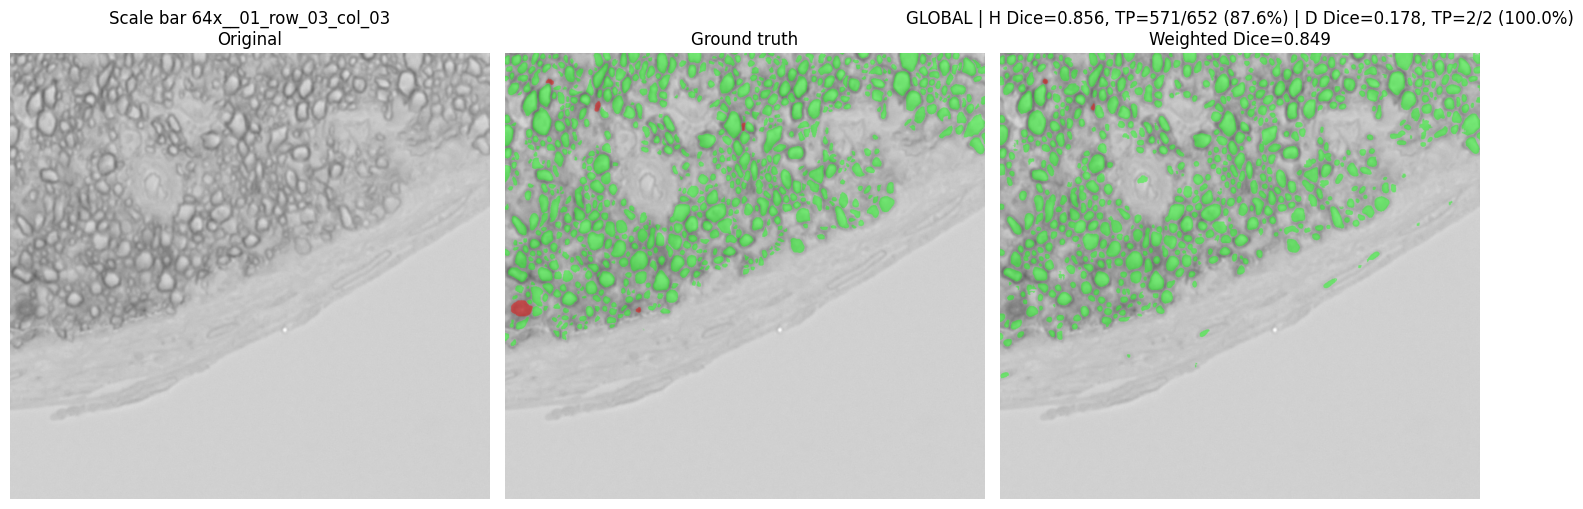

In [11]:
# ================================
# Cell 11: Specific FL model — post-processed GT vs prediction
# ================================
MODEL_ID="GLOBAL"   # "C1"..."C6" or "GLOBAL"
SOURCE="new_montage"   # "original", "new_montage", "axondeep"

ds=TEST_SETS[SOURCE]
posts=POST_MODEL_TEST_SETS[MODEL_ID][SOURCE]["post"]
ALPHA=.45
COLORS=np.array([[0,0,0],[0,255,0],[255,0,0]],np.uint8)

fig,axs=plt.subplots(len(ds["images"]),3,figsize=(15,5*len(ds["images"])))
if len(ds["images"])==1:axs=axs[None,:]

for i,(x,y,pred,name) in enumerate(tqdm(
    zip(ds["images"],ds["labels"],posts,ds["names"]),
    total=len(posts),desc=f"Plotting {MODEL_ID} → {SOURCE}")):

    img=np.clip(x.transpose(1,2,0),0,1)
    gt_color,pr_color=COLORS[y]/255.,COLORS[pred]/255.
    gt_overlay,pr_overlay=img.copy(),img.copy()
    gm,pm=y>0,pred>0
    gt_overlay[gm]=(1-ALPHA)*img[gm]+ALPHA*gt_color[gm]
    pr_overlay[pm]=(1-ALPHA)*img[pm]+ALPHA*pr_color[pm]

    hd,dd=binary_dice(pred,y,1),binary_dice(pred,y,2)
    hp,dp=(y==1).sum(),(y==2).sum()
    wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

    hm=match_instances(y==1,pred==1)
    dm=match_instances(y==2,pred==2)
    htp=100*hm["tp"]/hm["pred"] if hm["pred"] else 0
    dtp=100*dm["tp"]/dm["pred"] if dm["pred"] else 0

    axs[i,0].imshow(img)
    axs[i,0].set_title(f"{name}\nOriginal")

    axs[i,1].imshow(gt_overlay)
    axs[i,1].set_title("Ground truth")

    axs[i,2].imshow(pr_overlay)
    axs[i,2].set_title(
        f"{MODEL_ID} | H Dice={hd:.3f}, TP={hm['tp']}/{hm['pred']} ({htp:.1f}%) | "
        f"D Dice={dd:.3f}, TP={dm['tp']}/{dm['pred']} ({dtp:.1f}%)\n"
        f"Weighted Dice={wd:.3f}"
    )

    for ax in axs[i]:ax.axis("off")

plt.tight_layout()
plt.show()